## Example 3c:
Replication of example 3a, but using the flow-matching model instead of the MDN model. As discussed, the MDN model needed the min component allocation to be zeroed out before a calibrated model could be trained. The flow-matching model doesn't have that floor to begin with, though, so let's see if it does any better right out of the box.

In [1]:
import logging
import math
from pathlib import Path
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
get_default_velocity_config,
)
from cynosure.information.calibration import (
    calculate_rank_statistics,
    generate_and_predict,
    get_expected_rank_statistics,
    test_rank_uniformity,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.math_utilities import masked_mean, masked_stdev
from cynosure.utilities.training_utils import NoValidationBar, safe_load_from_checkpoint
from cynosure.zstack_decoding import ZstackSolver_FlowMatching
from cynosure.zstack_decoding.zstack_solver import twin_parity_signs

#### Simulation setup

In [4]:
use_pretrained = True  # enable to load weights from one of my checkpoints

train_cfg = get_default_training_config()
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config(
    min_photons=10_000,
    max_photons=10_000,
    max_background=0,
)
vel_cfg = get_default_velocity_config(num_sample_steps=200)

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)

In [5]:
rng_seed = 123
z_jitter = 1.5  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Fit a model

In [6]:
_ = pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_FlowMatching(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    vel_cfg=vel_cfg,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    noise_cfg=noise_cfg,
    hidden_channels=(32, 64),
    embedding_dims=128,
)
solver = solver.to(device)

Seed set to 123


In [7]:
checkpoint_path = Path("./pretrained_models/example_3c/checkpoints/final.ckpt")
if use_pretrained and checkpoint_path.is_file():
    solver = safe_load_from_checkpoint(checkpoint_path, solver).eval()
else:
    trainer = pl.Trainer(
        max_epochs=1000,
        accelerator=device,
        log_every_n_steps=100,
        callbacks=[NoValidationBar()],
        gradient_clip_val=1.0,
    )
    trainer.fit(solver)
    solver = solver.eval()

#### Assess initial calibration

In [8]:
_ = pl.seed_everything(rng_seed+1, workers=True)
solver = solver.to(device)

Seed set to 124


In [9]:
batch_size = 4096
num_samples = 511
num_bins = 32
chunk_size = 128

In [10]:
coef_blocks, pred_coef_blocks = generate_and_predict(solver, batch_size, num_samples, chunk_size)

In [11]:
ranks = [calculate_rank_statistics(cb, pcb, chunk_size) for (cb, pcb) in zip(coef_blocks, pred_coef_blocks)]
ranks = torch.cat(ranks, dim=-1)
ranks = ranks[:, ~solver.coefficients.is_pinned.cpu()]

In [12]:
uniform_mean, uniform_std = get_expected_rank_statistics(batch_size, num_bins)
pvalues = test_rank_uniformity(ranks, num_bins)

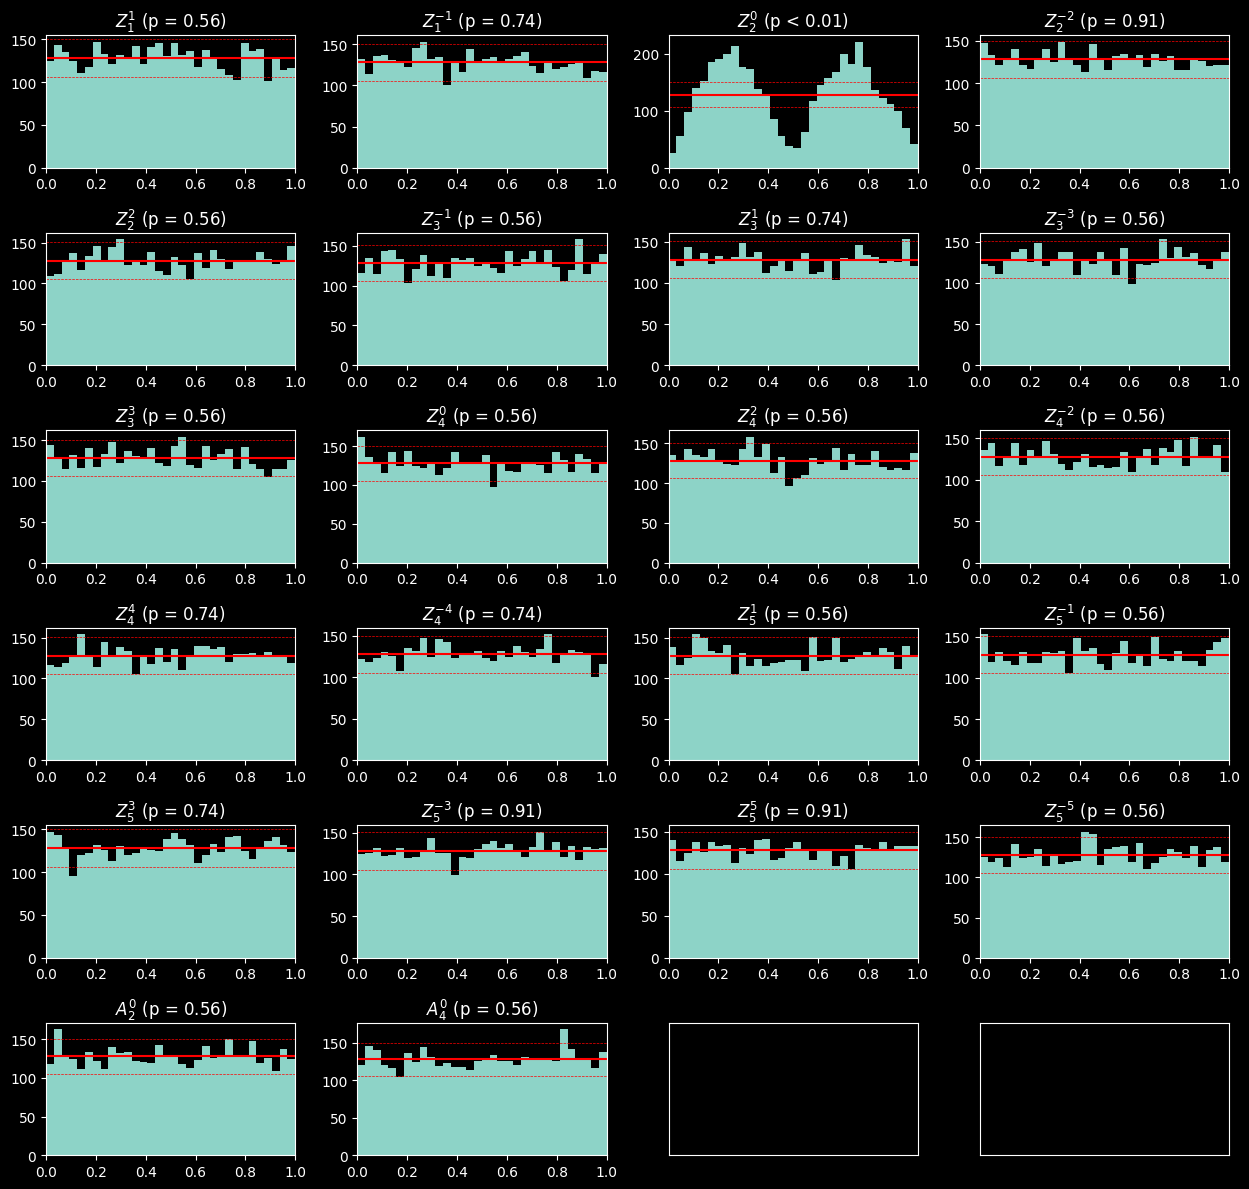

In [13]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7
num_coefs = ranks.shape[-1]

num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)
labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        out = ax.hist(ranks[:, i].numpy(force=True), range=(0, 1), bins=num_bins)
        ax.axhline(uniform_mean, ls="-", color="r")
        ax.axhline(uniform_mean - 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.axhline(uniform_mean + 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.set_ylim(bottom=0)
        ax.set_xlim(0, 1)

        p_lbl = f"p = {pvalues[i]:.2f}" if pvalues[i] > 0.01 else "p < 0.01"
        ax.set_title(f"{solver.coefficients.nonpinned_labels[i]} ({p_lbl})")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

Almost all of the coefficients look nicely calibrated, with the exception of $Z_2^0$. $Z_4^2$ looks a little suspicious by eye, but the statistics say it's just a coincidence. The defocus term $Z_2^0$ has an interesting, double-humped shape. As in example 3a, investigate by plotting the true coefficients vs. the predicted distributions.

#### Plotting true vs. predicted coefficients

Canonize signs across the focal plane degeneracy so we don't get a bunch of symmetric artifacts in the plots:

In [14]:
phase_signs = twin_parity_signs(solver.propagator.phase_projector.nm_indices, negate_even_n=True).cpu()
amp_signs = twin_parity_signs(solver.propagator.amp_projector.nm_indices, negate_even_n=False).cpu()
signs = torch.cat([phase_signs, amp_signs])
is_even = signs < 0

true_coefs = solver.coefficients.join(*coef_blocks)  # [B, N]
pred_coefs = solver.coefficients.join(*pred_coef_blocks)  # [B, S, N]

is_wrong_sign = (pred_coefs[..., is_even] * true_coefs[:, None, is_even]).sum(-1) < 0  # [B, S]
pred_coefs = torch.where(is_wrong_sign[..., None], pred_coefs * signs, pred_coefs)  # [B, S, N]

true_coefs = true_coefs[:, ~solver.coefficients.is_pinned.cpu()]
pred_coefs = pred_coefs[:, :, ~solver.coefficients.is_pinned.cpu()]

zscores = (pred_coefs.mean(1) - true_coefs) / pred_coefs.std(1)

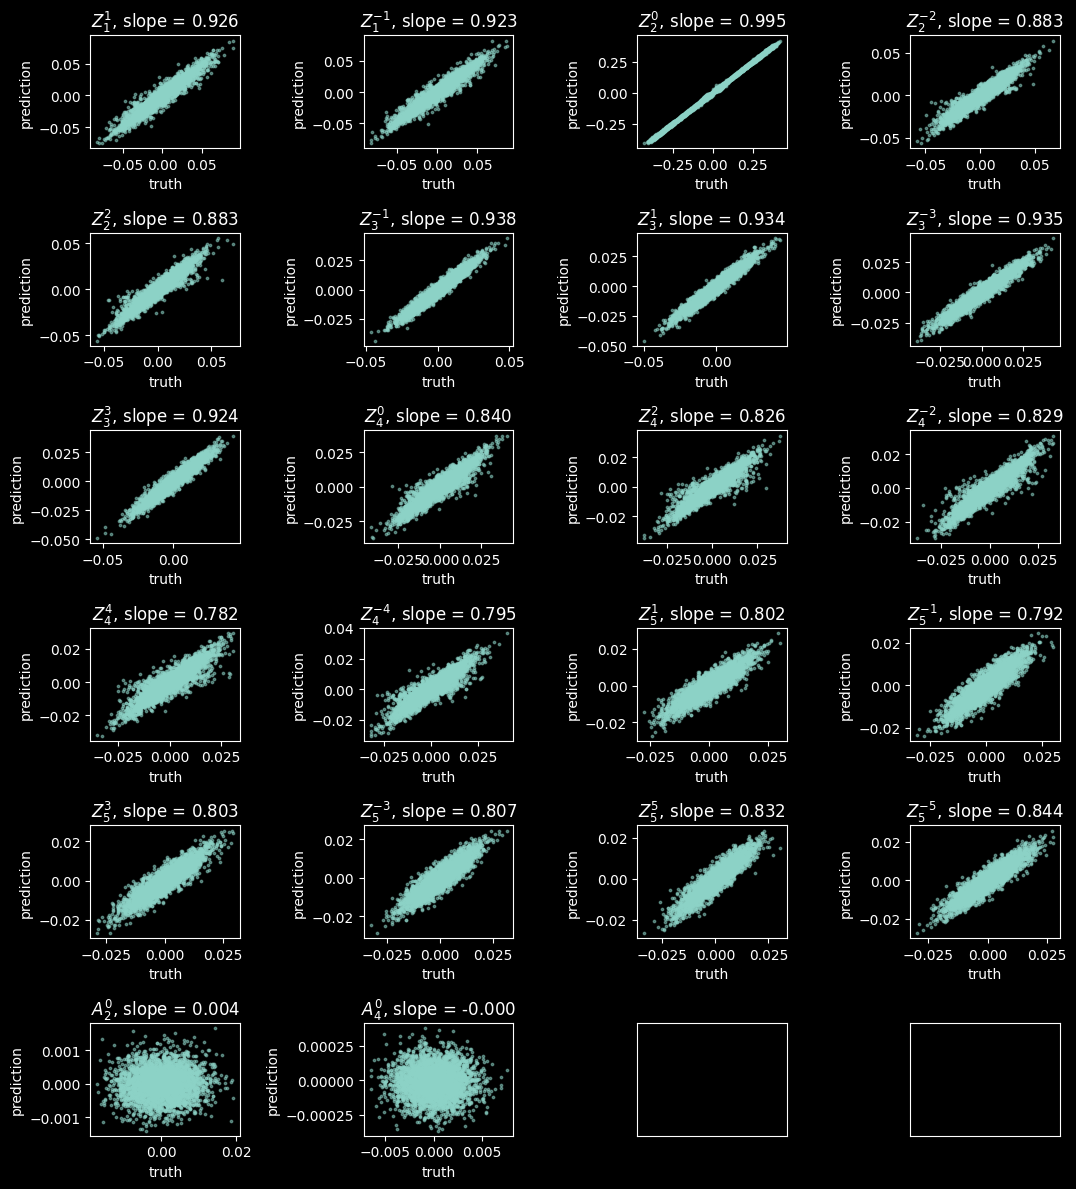

In [15]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.6

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        truth = true_coefs[:, i].numpy(force=True)  # [B,]
        preds = pred_coefs[:, :, i].mean(1).numpy(force=True)  # [B,]
        ax.scatter(truth, preds, s=3, alpha=0.5)

        slope = np.polyfit(truth, preds, deg=1)[0]
        ax.set_title(f"{labels[i]}, slope = {slope:.3f}")
        ax.set_ylabel("prediction")
        ax.set_xlabel("truth")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

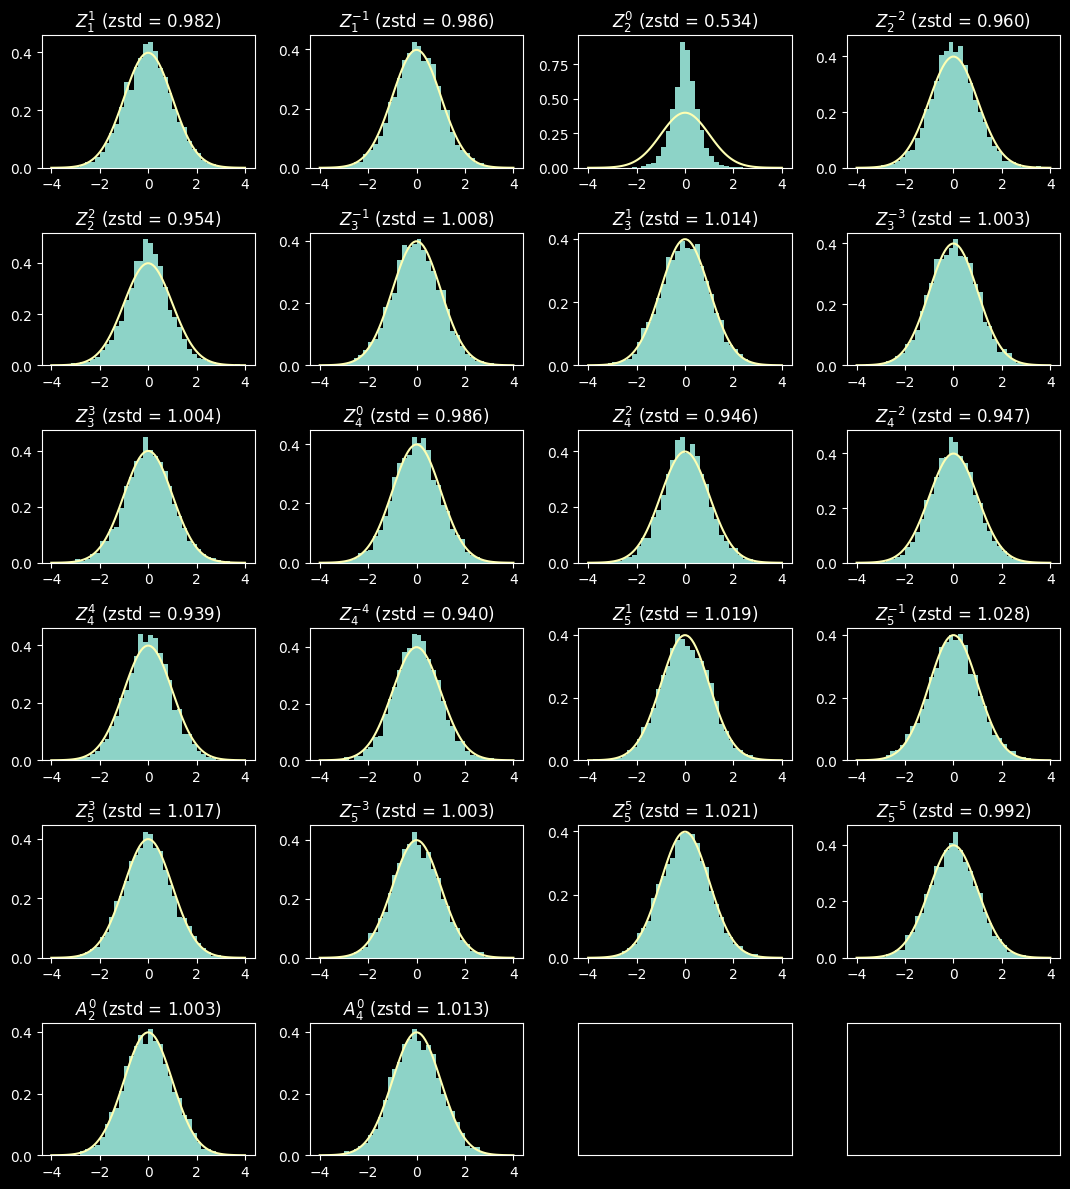

In [16]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.6

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

xmax = 4
x = np.linspace(-xmax, xmax, 100)
standard_normal = (1.0/math.sqrt(2*math.pi)) * np.exp(-0.5*x**2)

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        _ = ax.hist(zscores[..., i].numpy(force=True).ravel(), range=(-xmax, xmax), bins=40, density=True)
        ax.plot(x, standard_normal)
        ax.set_title(f"{solver.coefficients.nonpinned_labels[i]} (zstd = {zscores[..., i].std():.3f})")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

The predicted mean for $Z_2^0$ seems unbiased, with a slope of 1. Other phase coefficients generally have slopes around 0.8-0.9, although given that they span often an order of magnitude smaller ranges, it could be that they're just less tightly constrained by the model.

The predicted z-scores are all well-fitted by a standard normal distribution, except for $Z_2^0$, which shows significant underconfidence (predicted standard deviation is ~2x too large).

#### Hypothesis: predicted distribution is inflated by outliers

Visualizing the predicted distributions of $Z_2^0$ for a few dozen batch elements:

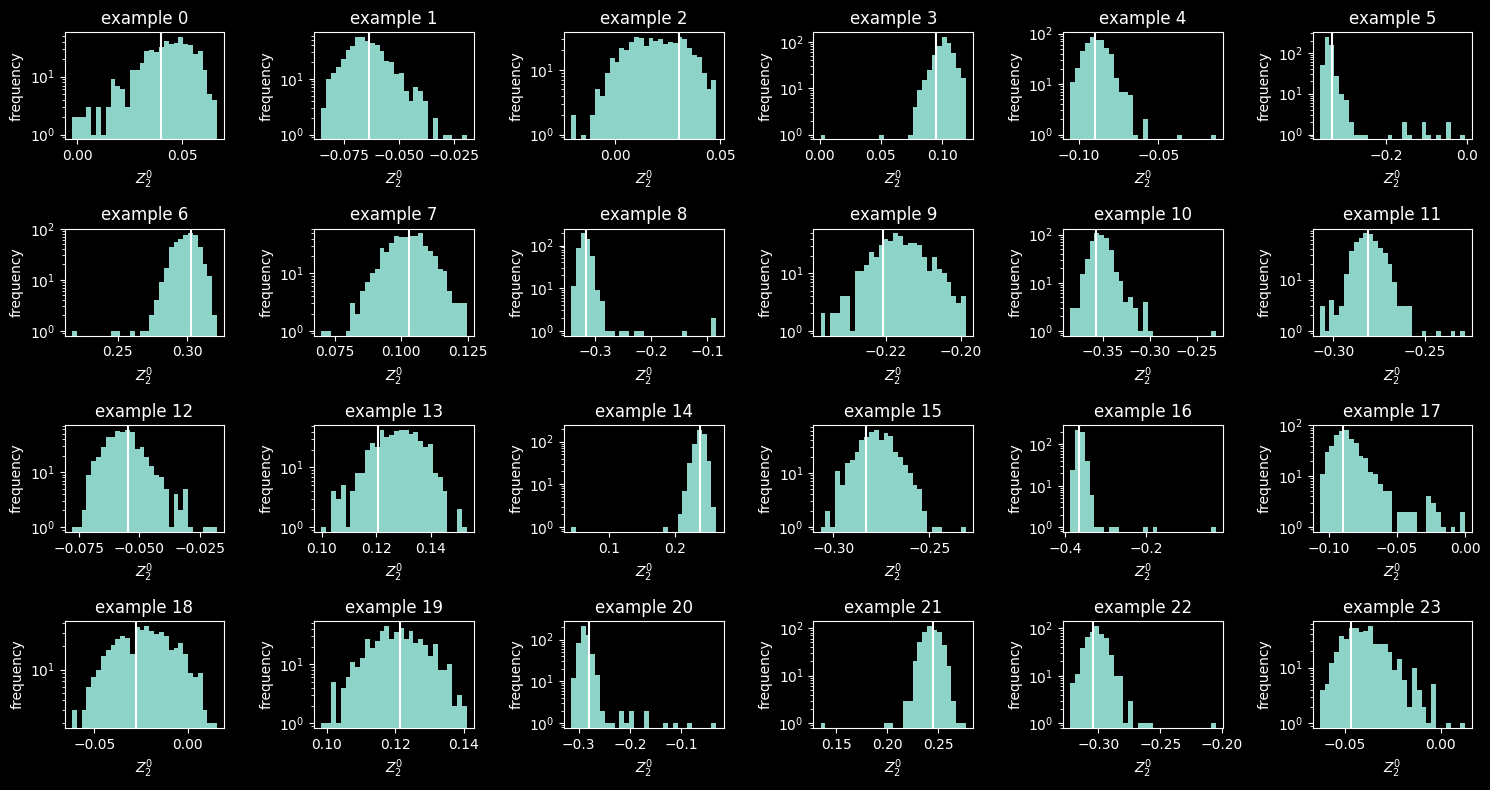

In [17]:
num_rows = 4
num_cols = 6
idx_z20 = solver.coefficients.nonpinned_labels.index("$Z_{2}^{0}$")
fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=(num_cols*2.5, num_rows*2))
for i, ax in enumerate(axarr.ravel()):
    _ = ax.hist(pred_coefs[i, :, idx_z20].numpy(force=True), bins=30)
    ax.axvline(true_coefs[i, idx_z20])
    ax.set_yscale("log")
    ax.set_title(f"example {i}")
    ax.set_xlabel("$Z_{2}^{0}$")
    ax.set_ylabel("frequency")
fig.tight_layout()

A lot of these distributions show a long tail towards 0. Given that $Z_2^0$ is where we expect the focal plane degeneracy to show up most strongly, maybe this is some sort of mode crossing, with probability "leaking" across into the degenerate mode and skewing the standard deviation?

Let's see if the z-score distributions clean up if we exclude outliers on the towards-zero side.

In [18]:
outlier_bounds = torch.quantile(pred_coefs, torch.Tensor([0.02, 0.98], device=pred_coefs.device), dim=1)  # [2, B, N]
is_low_outlier = (pred_coefs > 0) & (pred_coefs < outlier_bounds[0].unsqueeze(1))
is_high_outlier = (pred_coefs < 0) & (pred_coefs > outlier_bounds[1].unsqueeze(1))
is_outlier = is_low_outlier | is_high_outlier  # [B, S, N]

zscores_inliers = (masked_mean(pred_coefs, is_outlier, 1) - true_coefs) / masked_stdev(pred_coefs, is_outlier, 1)

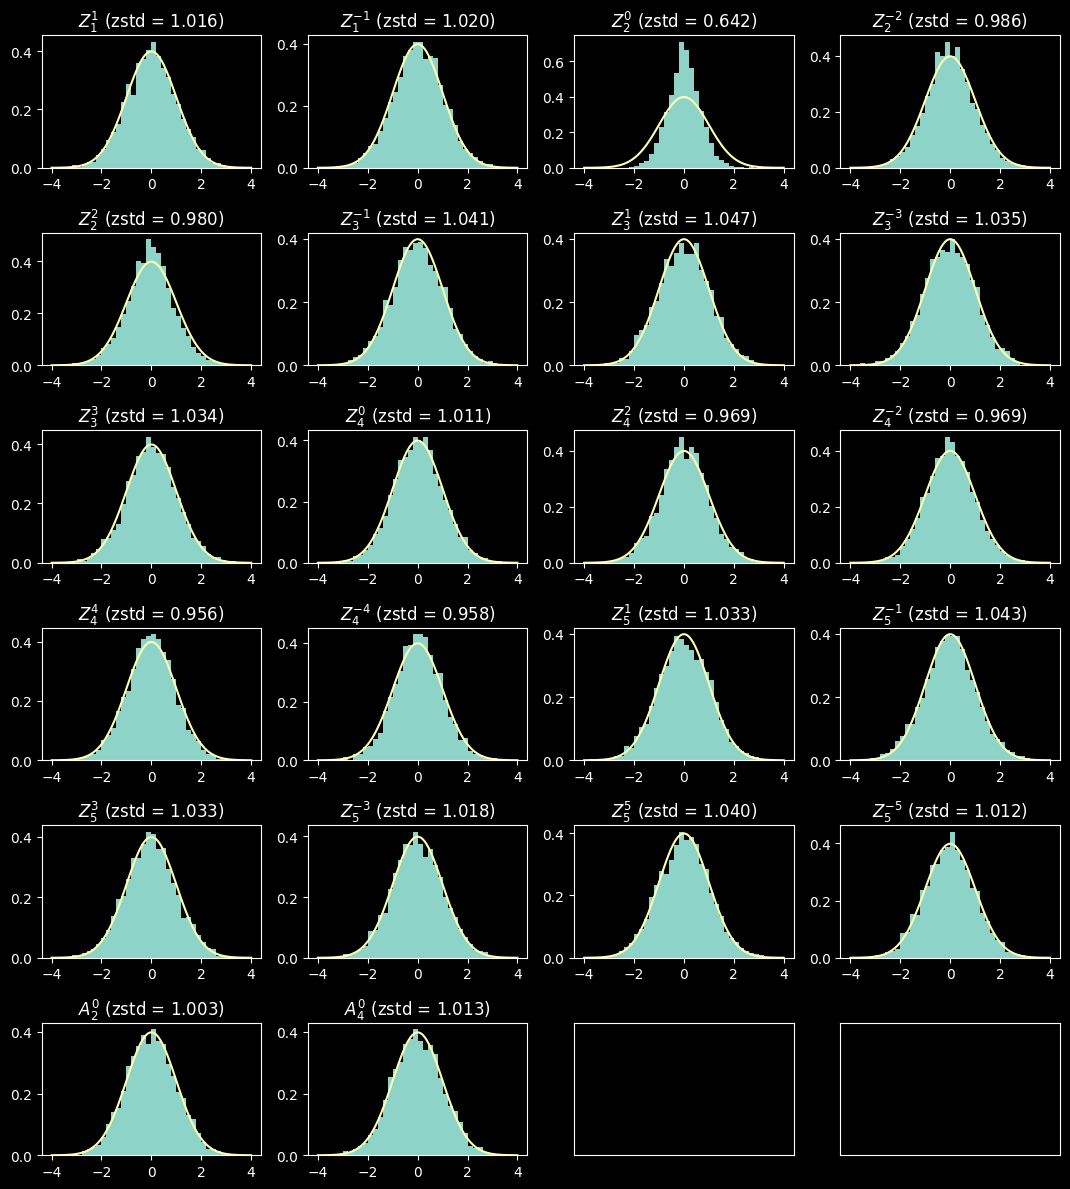

In [19]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.6

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

xmax = 4
x = np.linspace(-xmax, xmax, 100)
standard_normal = (1.0/math.sqrt(2*math.pi)) * np.exp(-0.5*x**2)

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        _ = ax.hist(zscores_inliers[..., i].numpy(force=True).ravel(), range=(-xmax, xmax), bins=40, density=True)
        ax.plot(x, standard_normal)
        ax.set_title(f"{solver.coefficients.nonpinned_labels[i]} (zstd = {zscores_inliers[..., i].std():.3f})")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

Seems encouraging. Excluding 2 percentile on the side closer to 0 causes all z-scores to widen slightly, as expected, but $Z_2^0$ shows a much larger increase towards the standard normal. Redo at different percentile exclusions to see how things change:

In [20]:
pct_list = [0.2*i for i in range(21)]
zscores_inliers_stdev = []

for pct in pct_list:
    outlier_bounds = torch.quantile(pred_coefs, torch.Tensor([pct/100, 1-pct/100], device=pred_coefs.device), dim=1)  # [2, B, N]
    is_low_outlier = (pred_coefs > 0) & (pred_coefs < outlier_bounds[0].unsqueeze(1))
    is_high_outlier = (pred_coefs < 0) & (pred_coefs > outlier_bounds[1].unsqueeze(1))
    is_outlier = is_low_outlier | is_high_outlier  # [B, S, N]

    zscores_inliers = (masked_mean(pred_coefs, is_outlier, 1) - true_coefs) / masked_stdev(pred_coefs, is_outlier, 1)
    zscores_inliers_stdev.append(zscores_inliers.std(0).numpy(force=True))

zscores_inliers_stdev = np.stack(zscores_inliers_stdev)

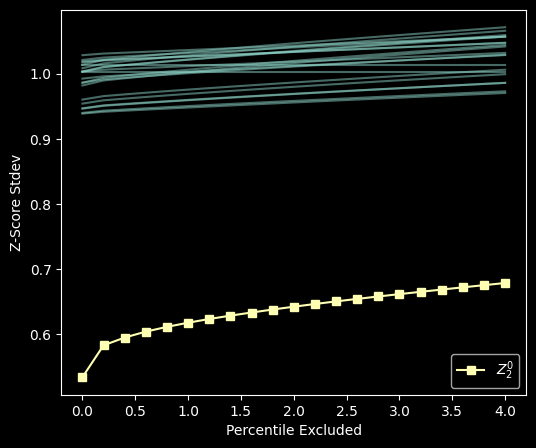

In [21]:
fig, ax = pyplot.subplots(figsize=(6, 5))
_ = ax.plot(pct_list, zscores_inliers_stdev[:, np.arange(zscores_inliers_stdev.shape[1]) != idx_z20], "-", color="C0", alpha=0.5)
_ = ax.plot(pct_list, zscores_inliers_stdev[:, idx_z20], "s-", color="C1", label="$Z_2^0$")
ax.set_xlabel("Percentile Excluded")
ax.set_ylabel("Z-Score Stdev")
_ = ax.legend(loc="lower right")

The $Z_2^0$ term's z-score standard deviation increases rapidly as the first ~quarter-percentile is excluded, but the trend quickly saturates to the same, roughly linear behavior that the other coefficients show (i.e., the boring regime where the z-score is just widening because we're cropping the edges of the normal distribution). So removing the outliers helps, but is only part of the problem.

#### Hypothesis: calculate rank statistics separately within each degenerate state

$Z_2^0$ is both the largest-magnitude coefficient and also the one that most clearly shows the focal plane degeneracy. That seems like a likely candidate for the odd, two-humped shape in its rank statistic distribution. Recalculate using the sign-canonized coefficients from above:

In [22]:
ranks_canon = calculate_rank_statistics(true_coefs, pred_coefs, chunk_size)  # [B, N]
pvalues_canon = test_rank_uniformity(ranks_canon, num_bins)

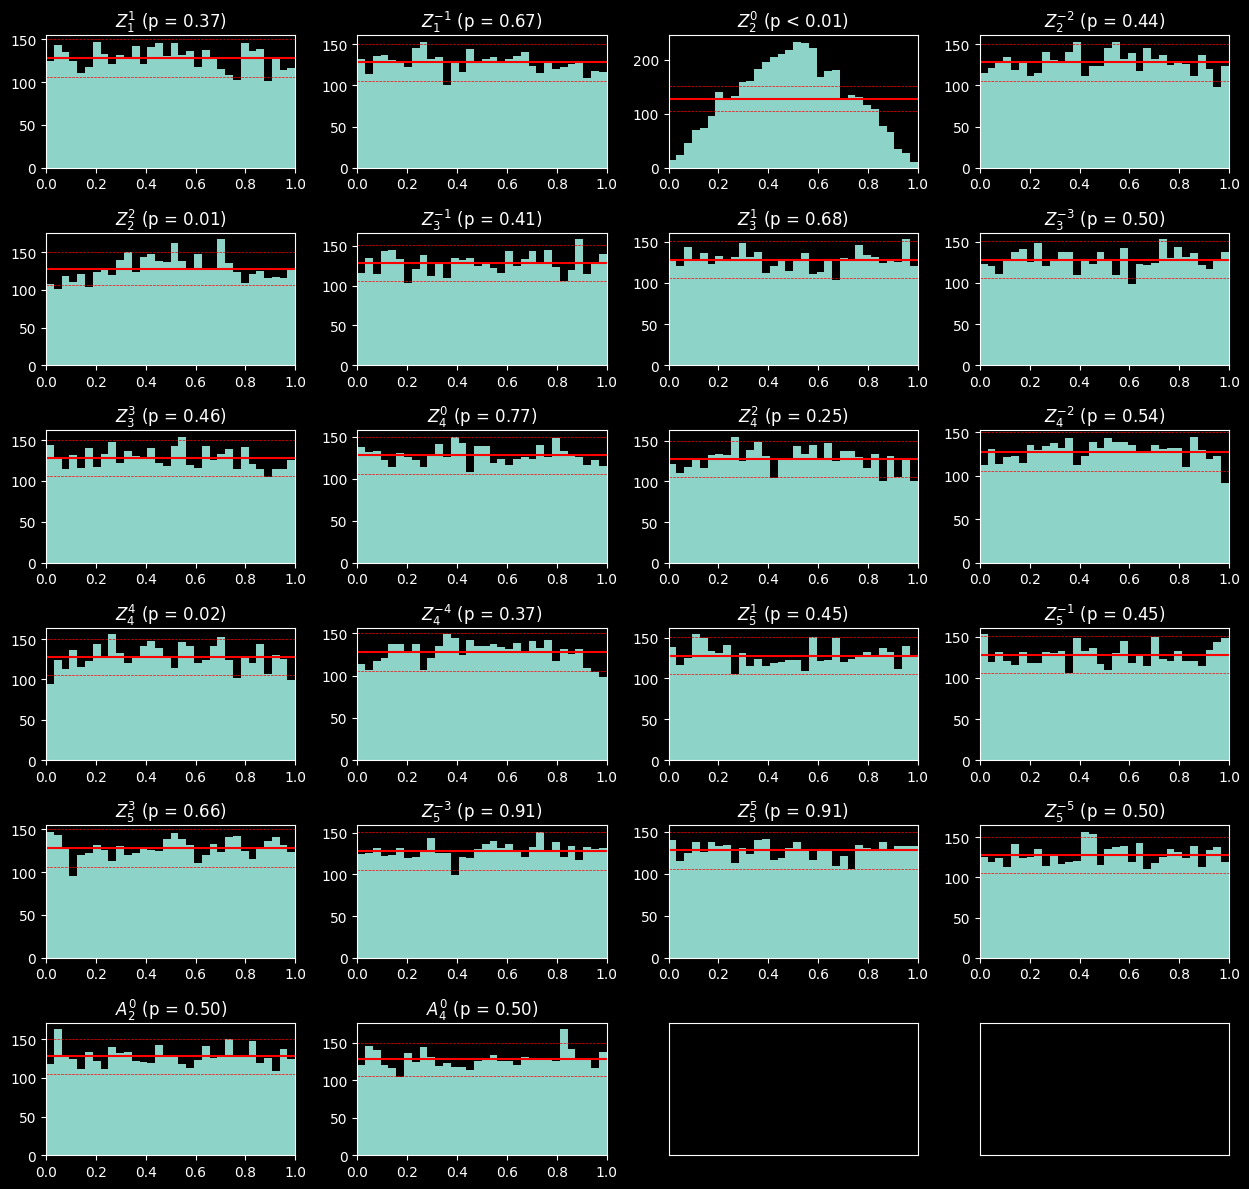

In [23]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7
num_coefs = ranks.shape[-1]

num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)
labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        out = ax.hist(ranks_canon[:, i].numpy(force=True), range=(0, 1), bins=num_bins)
        ax.axhline(uniform_mean, ls="-", color="r")
        ax.axhline(uniform_mean - 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.axhline(uniform_mean + 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.set_ylim(bottom=0)
        ax.set_xlim(0, 1)

        p_lbl = f"p = {pvalues_canon[i]:.2f}" if pvalues_canon[i] > 0.01 else "p < 0.01"
        ax.set_title(f"{solver.coefficients.nonpinned_labels[i]} ({p_lbl})")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

Well at least the $Z_2^0$ term is now an easier-to-interpret, single hump, classically indicative of the underconfidence we've already observed. It could be that the model just has trouble compressing the wide-ranging defocus term into a tight posterior distribution. Maybe a change in normalization or whitening would help?